In [2]:
import matplotlib.pyplot as plt
import numpy as np

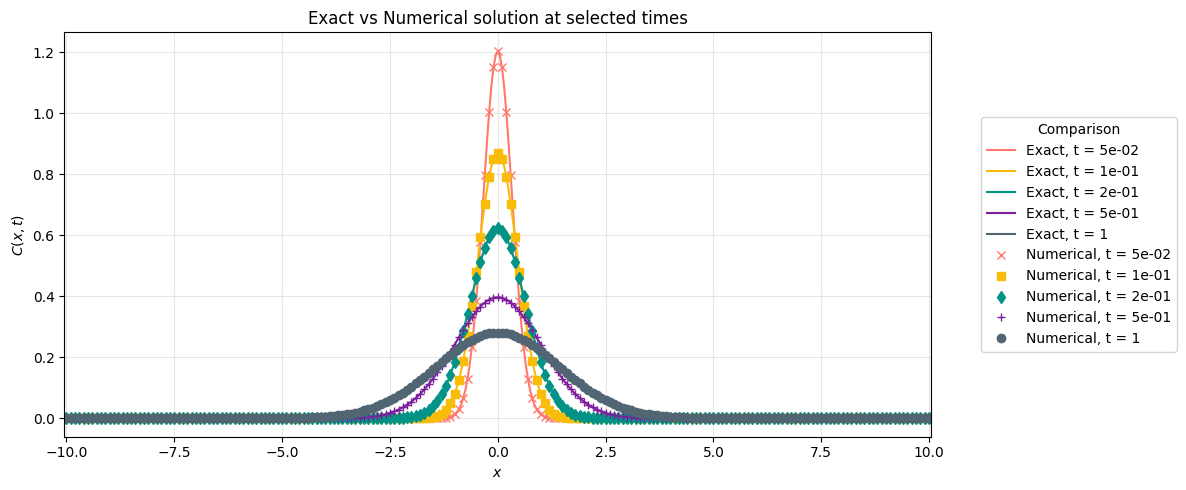

In [2]:
# --- Plotting Function ---
def plotting(U, x, t, analytic_solution):
    """
    Plots the numerical and exact solutions at selected time steps.
    """
    # Grid spacing and basic info
    dx = x[1] - x[0]
    N = len(t) - 1
    T = t[-1]

    markers = ['x','s','d','+','o','.']
    colours = ['xkcd:salmon','xkcd:golden rod','xkcd:teal',
               'xkcd:purple','xkcd:slate','xkcd:silver']

    # Choose display times (spread over [0, T])
    idxs = [max(1, N//20), max(1, N//10), max(1, N//5), max(1, N//2), N]
    idxs = sorted(set(min(N, i) for i in idxs)) # deduplicate & clip

    fig, ax = plt.subplots(1, 1, figsize=(12, 5))

    # --- Plot "Exact" Solution ---
    for k, idx_t in enumerate(idxs):
        τ = t[idx_t]
        time_str = (f't = {τ:.0e}' if 0 < τ < T else f't = {τ:.0f}')
        lbl = f'Exact, {time_str}'
        line, = ax.plot(x, analytic_solution(x, τ),
                        color=colours[k % len(colours)], label=lbl)

    # --- Plot Numerical ---
    for k, idx_t in enumerate(idxs):
        τ = t[idx_t]
        time_str = (f't = {τ:.0e}' if 0 < τ < T else f't = {τ:.0f}')
        lbl = f'Numerical, {time_str}'
        # plot every other spatial point just for readability
        line, = ax.plot(x[::2], U[idx_t][::2],
                        linestyle='', marker=markers[k % len(markers)],
                        color=colours[k % len(colours)], label=lbl)

    # Create Legends
    ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title='Comparison')

    ax.set_xlim(x.min() - dx, x.max() + dx)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$C(x,t)$")
    ax.set_title("Exact vs Numerical solution at selected times")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



# Set up
Nx_spaces = 400      # number of intervals
L = 10
Nx_points = Nx_spaces + 1
x = np.linspace(-L, L, Nx_points)

Nt_gaps = 30000
T = 1.0
Nt_points = Nt_gaps + 1
t = np.linspace(0., T, Nt_points)


dx = x[1] - x[0]
dt = t[1] - t[0]
t_exact = Nt_gaps * dt
D = 1.0 

# Initial condition
sigma0 = 2*dx # A very narrow Gaussian
u = (1.0 / np.sqrt(2*np.pi*(sigma0**2))) * np.exp(-(x)**2 / (2*sigma0**2))
u0 = u.copy()

# Analytic Solution
def analytic_solution(x, t_exact):
    u_exact = 1 / np.sqrt(2 * np.pi * (sigma0 ** 2 + 2 * t_exact)) * np.exp(-(x**2) / (2*(sigma0**2 + 2*t_exact)))
    return u_exact

# storage for all times
U = np.zeros((Nt_gaps + 1, Nx_points))
U[0] = u0.copy()

C = D * dt / dx**2 

for n in range(Nt_gaps):
    u_new = u.copy()

    for j in range(1, Nx_points - 1):
        u_new[j] = u[j] + C * (u[j+1] - 2*u[j] + u[j-1])

    # Neumann BCs (zero flux): mirror
    u_new[0]  = u_new[1]
    u_new[-1] = u_new[-2]

    u = u_new
    U[n + 1] = u


# We pass the screen bounds to the plotting function
plotting(U, x, t, analytic_solution)

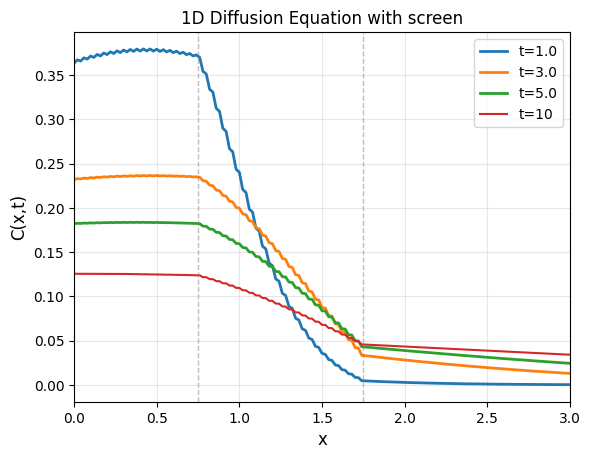

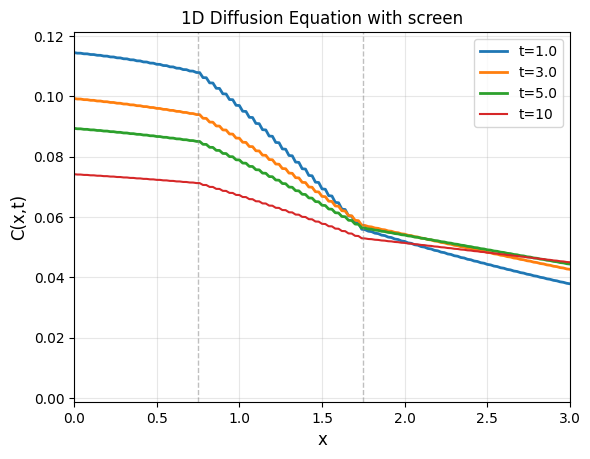

In [3]:
# --- Implementation of Eulers method with CFD --- 
Nx_spaces = 1000     
L = 10
Nx_points = Nx_spaces + 1
x = np.linspace(-L, L, Nx_points)

N = 33000
T = 10
Nt_points = N + 1
t = np.linspace(0, T, Nt_points)

dx = x[1] - x[0]
dt = t[1] - t[0]
C = dt / (2 * dx)

# Diffusion coefficient
def make_D(x, alpha, w):
    D = np.ones_like(x)
    D[np.abs(x - 1.25) <= w/2] = alpha   # reduce diffusion inside the screen region
    return D

screen = 1.25
w = 1
alphas = [0.1,0.3]


# Initial condition: Gaussian δ(x)
sigma = 2 * dx
u = (1 / np.sqrt(2 * np.pi * sigma**2)) * np.exp(-(x)**2 / (2 * sigma**2))
u0 = u.copy()

# Times to save and plot
save_times = [1, 3, 5, 10]
save_indices = [int(t_val / dt) for t_val in save_times]
u_solutions = {}

for alpha in alphas:
    D = make_D(x, alpha, w)
    # Forward Euler time stepping
    F = np.zeros_like(D)
    for n in range(N):
        u_new = u.copy()
        for j in range(1, Nx_points - 1):
            F[j] = D[j] * ((u[j+1] - u[j-1]) / (2 * dx) )
            u_new[j] = u[j] + C * (F[j+1] - F[j-1])
        # Neumann BCs
        u_new[0] = u_new[1]
        u_new[-1] = u_new[-2]
        u = u_new

        # Save solutions at specified times
        if n in save_indices:
            u_solutions[n * dt] = u.copy()
            
    actual_times = sorted(u_solutions.keys())

    for i, t_key in enumerate(actual_times):
        plt.plot(x, u_solutions[t_key], 
                label=f't={t_key:.1f}', linewidth=2)
    plt.plot(x, u, label=f't={T}')
    plt.axvline(x=screen - w/2, linestyle='--', color='gray', lw=1, alpha=0.5)
    plt.axvline(x=screen + w/2, linestyle='--', color='gray', lw=1, alpha=0.5)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('C(x,t)', fontsize=12)
    plt.title('1D Diffusion Equation with screen')
    plt.grid(True, alpha=0.3)
    plt.xlim(left = 0, right = 3)
    plt.legend()
    plt.show()

In [ ]:
# Set up
Nx_spaces = 1000     
L = 10
Nx_points = Nx_spaces + 1
x = np.linspace(-L, L, Nx_points)

N = 30000
T = 3
Nt_points = N + 1
t = np.linspace(0, T, Nt_points)

dx = x[1] - x[0]
dt = t[1] - t[0]
C = dt / (2 * dx)

# Setting the different screen widths to test
screen = 1.25
ws = [0.003,0.005,0.007]
alpha = 1e-15

sigma = 2 * dx
u = (1 / np.sqrt(2 * np.pi * sigma**2)) * np.exp(-(x)**2 / (2 * sigma**2))

# Running the forward Euler algorithm for different widths
for w in ws:
    D = make_D(x, alpha, w)
    # Forward Euler time stepping
    F = np.zeros_like(D)
    for n in range(N):
        u_new = u.copy()
        for j in range(1, Nx_points - 1):
            F[j] = D[j] * ((u[j+1] - u[j-1]) / (2 * dx) )
            u_new[j] = u[j] + C * (F[j+1] - F[j-1])
        # Neumann BCs
        u_new[0] = u_new[1]
        u_new[-1] = u_new[-2]
        u = u_new

    # Solving the Riemann sums after the screen by applying a boolean array to the x values 
    cond = x >= screen + w/2 
    x_filtered = x[cond]
    u_t3 = u[cond]
    # Summing all the points that map to a TRUE value * step size
    riemann_sum_t3 = np.sum(u_t3) * dx

    print(f"Riemann sum for alpha = {alpha} and width w ={w}: {riemann_sum_t3}")

#------------------------------------------------------------------------------------------------
# Please not that the result from this cell was not used for our numerics but the method was used
# with different parameters that could not be recovered
#------------------------------------------------------------------------------------------------

Riemann sum for alpha = 1e-15 and width w =0.003: 0.30516336711553377
Riemann sum for alpha = 1e-15 and width w =0.005: 0.3595645355734817
Riemann sum for alpha = 1e-15 and width w =0.007: 0.38479026253105186


In [ ]:
# Setting the different alpha values to test
alphas = [0.1,0.3,1]
screen = 1.25
w = 0.1

Nx_spaces = 1000
L = 10
Nx_points = Nx_spaces + 1
x = np.linspace(-L, L, Nx_points)

N = 30000
T = 10
Nt_points = N + 1
t = np.linspace(0, T, Nt_points)

dx = x[1] - x[0]
dt = t[1] - t[0]
C = dt / (2 * dx)

sigma = 2 * dx
u = (1 / np.sqrt(2 * np.pi * sigma**2)) * np.exp(-(x)**2 / (2 * sigma**2))
u0 = u.copy()


# Running the Forward Euler algorithm to test the model at different alpha 
for alpha in alphas:
    D = make_D(x, alpha, w)

    u = (1 / np.sqrt(2 * np.pi * sigma**2)) * np.exp(-(x)**2 / (2 * sigma**2))
    # Dictionary to store different time stamps at
    u_solutions_temp = {}
    F = np.zeros_like(D)
    for n in range(N):
        u_new = u.copy()
        for j in range(1, Nx_points - 1):
            F[j] = D[j] * ((u[j+1] - u[j-1]) / (2 * dx))
            u_new[j] = u[j] + C * (F[j+1] - F[j-1])

            # Neumann BCs
            u_new[0] = u_new[1]
            u_new[-1] = u_new[-2]
            u = u_new

            if n == int(3.0 / dt):
                u_solutions_temp[3.0] = u.copy()

    # New method for how to find the correct index to start summing from 
    t = 3
    x_cutoff = screen + w/2
    u_t3 = u_solutions_temp[t]

    # Find the first index where x >= cutoff
    j_start = np.searchsorted(x, x_cutoff)
    riemann_sum = np.sum(u_t3[j_start:]) * dx
    print(f"Riemann sum at t=3 at alpha = {alpha}: {riemann_sum}")

Riemann sum at t=3 at alpha = 0.1: 0.24325553681314294
Riemann sum at t=3 at alpha = 0.3: 0.28351360534440007
Riemann sum at t=3 at alpha = 1: 0.29957917876691403
